# Information-Theoretic Acquisition Functions

[_Link to Tutorial on BoTorch_](https://botorch.org/docs/tutorials/information_theoretic_acquisition_functions/)

_Drew Gjerstad_

**Includes content from BoTorch's documentation.**

In this tutorial, we will focus on information-theoretic acquisition functions and how to implement them in BoTorch. Additionally, we will review both single- and multi-objective optimization examples using information-theoretic acquisition functions.

## Notation
Before jumping into the implementation part of this tutorial, we will establish some notation for our optimization setting. First, consider the single-objective setting where we maximize a function $f: \mathbb{X} \rightarrow \mathbb{R}^{M}$ with $M=1$. In the single-objective setting, the maximum is defined using a total order over the real numbers. In the multi-objective setting ($M > 1$), the maximum is defined using the Pareto partial ordering over vectors. We follow BoTorch's notation to denote the optimal set of inputs and outputs:

\begin{equation*}
    \mathbb{X}^{*} = \argmax_{\mathbf{x}\in\mathbb{X}} f(\mathbf{x})
        \subseteq \mathbb{X}
    \hspace{12pt}\text{and}\hspace{12pt}
    \mathbb{Y}^{*} = \max_{\mathbf{x}\in\mathbb{X}} f(\mathbf{x})
        \subset \mathbb{R}^{M}
\end{equation*}

From the notation above, the collection of optimal input-output pairs is denoted by $(\mathbb{X}^{*}, \mathbb{Y}^{*})$.

## Overview of Information-Theoretic Acquisition Functions
The notion of information-theoretic acquisition functions is to use information theory when determining the utility of an input $\mathbf{x}\in\mathbb{X}$. In particular, we consider how informative the corresponding observation $\mathbf{y}\in\mathbb{R}^{M}$ will be to learn more about the distribution of some stochastic process of the function denoted by $S(f)$. Typically, information-theoretic acquisition functions use **mutual information (MI)** to define the utility of data:

\begin{equation*}
    \alpha^{\text{IT}}(\mathbf{x}\vert D_{n}) =
    \text{MI}(\mathbf{y}; S(f)\vert \mathbf{x}, D_{n}) =
    H\left[p(\mathbf{y}\vert D_{n})\right] -
    \mathbb{E}_{p(S(f)\vert D_{n})}
    \left[H\left[p(\mathbf{y}\vert\mathbf{x}), D_{n}, S(f)\right]\right]
\end{equation*}

where $D_{n} = (\mathbf{x}_t, \mathbf{y}_t)_{t=1,\dots,n}$ denotes the data set of sampled inputs and observations and $H$ denotes the differential entropy. In literature, the difference between information-theoretic acquisition functions is the choice of statistic $S$ and the modeling assumptions made in order to estimate the resulting acquisition function. Therefore, we will review three particular cases: predictive entropy search, max-value entropy search, and joint entropy search.

### Predictive Entropy Search (PES)
The predictive entropy search acquisition function considers the problem of learning more about the distribution of **optimal inputs**: $S(f) = \mathbb{X}^{*}$. The PES acquisition function is given by:

\begin{equation*}
    \alpha^{\text{PES}}(\mathbf{x}\vert D_{n}) =
    \text{MI}(\mathbf{y};\mathbb{X}^{*}\vert\mathbf{x},D_{n}) =
    H\left[p(\mathbf{y}\vert D_{n})\right] -
    \mathbb{E}_{p(\mathbb{X}^{*}\vert D_{n})}
    \left[H\left[p(\mathbf{y}\vert\mathbf{x}),D_{n},\mathbb{X}^{*}\right]\right]
\end{equation*}

### Max-value Entropy Search (MES)
The max-value entropy search acquisition function considers the problem of learning more about the distribution of the **optimal outputs**: $S(f) = \mathbb{Y}^{*}$. The MES acquisition function is given by:

\begin{equation*}
    \alpha^{\text{MES}}(\mathbf{x}\vert D_{n}) =
    \text{MI}(\mathbf{y};\mathbb{Y}^{*}\vert\mathbf{x},D_{n}) =
    H\left[p(\mathbf{y}\vert D_{n})\right] -
    \mathbb{E}_{p(\mathbb{Y}^{*}\vert D_{n})}
    \left[H\left[p(\mathbf{y}\vert\mathbf{x}),D_{n},\mathbb{Y}^{*}\right]\right]
\end{equation*}

### Joint Entropy Search (JES)
The joint entropy search acquisition function considers the problem of learning more about the distribution of the **pairs of optimal inputs and outputs**: $S(f) = (\mathbb{X}^{*},\mathbb{Y}^{*})$. The JES acquisition function is given by:

\begin{equation*}
    \alpha^{\text{JES}}(\mathbf{x}\vert D_{n}) =
    \text{MI}(\mathbf{y};(\mathbb{X}^{*},\mathbb{Y}^{*})\vert\mathbf{x},D_{n}) =
    H\left[p(\mathbf{y}\vert D_{n})\right] -
    \mathbb{E}_{p((\mathbb{X}^{*},\mathbb{Y}^{*})\vert D_{n})}
    \left[H\left[
        p(\mathbf{y}\vert\mathbf{x}),D_{n},(\mathbb{X}^{*},\mathbb{Y}^{*})
    \right]\right]
\end{equation*}

## Single-Objective Example
We will now work through a single-objective example of information-theoretic acquisition functions in BoTorch. In particular, we will examine a simplistic, one-dimensional example with one objective.

In [16]:
# Load Dependencies
import os
import matplotlib.pyplot as plt
import numpy as np
import torch

from botorch.fit import fit_gpytorch_mll
from botorch.models.gp_regression import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.utils.sampling import draw_sobol_samples
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood

In [2]:
SMOKE_TEST = os.environ.get("SMOKE_TEST")
tkwargs = {"dtype": torch.double, "device": "cpu"}

First, we will define the objective function.

In [3]:
# Define Objective Function
def f(x):
    p1 = torch.cos(torch.pi * x)
    p2 = 10 * torch.sin(torch.pi * x)
    p3 = 2 * torch.sin(2 * torch.pi * x)
    p4 = 2 * torch.sin(6 * torch.pi * x)
    return p1 + p2 + p3 + p4

# Define Bounds
bounds = torch.tensor([[0.0], [1.0]], **tkwargs)

Next, we will generate some data and use it to fit the GP model.

In [4]:
torch.manual_seed(0)
np.random.seed(0)
n = 5
train_X = draw_sobol_samples(bounds=bounds, n=n, q=1, seed=12345678).squeeze(-2)
train_Y = f(train_X)

# Fit GP Model
def fit_model(train_X, train_Y, n_outputs):
    model = SingleTaskGP(
        train_X=train_X,
        train_Y=train_Y,
        outcome_transform=Standardize(m=n_outputs)
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model

model = fit_model(train_X, train_Y, n_outputs=1)

Now, we will plot the objective function and the fitted model.

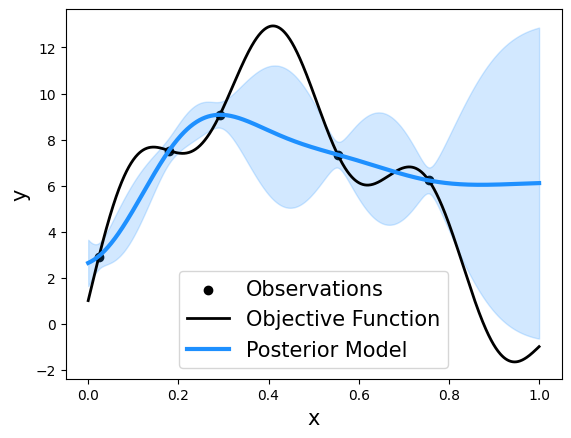

In [5]:
# Plot Objective Function and Fitted GP Model
X = torch.linspace(bounds[0, 0], bounds[1, 0], 1000, **tkwargs)
mean_fX = model.posterior(X).mean.squeeze(-1).detach().numpy()
std_fX = torch.sqrt(model.posterior(X).variance).squeeze(-1).detach().numpy()

plt.scatter(train_X, train_Y, color="k", label="Observations")
plt.plot(X, f(X), color="k", linewidth=2, label="Objective Function")
plt.plot(X, mean_fX, color="dodgerblue", linewidth=3, label="Posterior Model")
plt.fill_between(
    X, (mean_fX + 3 * std_fX), (mean_fX - 3 * std_fX), alpha=0.2, color="dodgerblue"
)
plt.xlabel("x", fontsize=15)
plt.ylabel("y", fontsize=15)
plt.legend(fontsize=15)
plt.show()

Before we can compute information-theoretic acquisition functions, we need to obtain Monte Carlo samples of the optimal inputs and outputs. We can use BoTorch's `sample_optimal_points` method to generate `n_samples` approximate samples of the GP model and optimizes them sequentially using an optimizer.

Since we are in the single-objective setting, `n_points` should be set to one. Note that for simplicity, the tutorial uses optimization via random search.

In [6]:
# Obtain Monte Carlo Samples
from botorch.acquisition.utils import get_optimal_samples

n_samples = 12

optimal_inputs, optimal_outputs = get_optimal_samples(
    model=model,
    bounds=bounds,
    num_optima=n_samples
)

After obtaining the Monte Carlo samples, we can now initialize the information-theoretic acquisition functions. For PES, we only need the optimal set of inputs. However, for MES and JES, it is also required that we specify the region of integration: $\mathbf{y}:\mathbf{y}\preceq\mathbb{Y}^{*}$ for a maximization problem. To specify the region of integration in BoTorch we can provide a Tensor of bounds using the `compute_sample_box_decomposition` method.

Be aware that for MES, we will use the multi-objective implementation since it implements all the types of estimation into a single acquisition function. There are also other strategies to estimate single-objective MES algorithms in the `botorch.acquisition.max_value_entropy` module.

Finally, in the code below we use the lower bound estimates for MES and JES. For single-objective MES, the interface is different in that it uses the Gumbel max-value approximation that does not require max values as input.

In [7]:
# Initialize Acquisition Functions
from botorch.acquisition.predictive_entropy_search import qPredictiveEntropySearch
from botorch.acquisition.max_value_entropy_search import qLowerBoundMaxValueEntropy
from botorch.acquisition.joint_entropy_search import qJointEntropySearch

pes = qPredictiveEntropySearch(model=model, optimal_inputs=optimal_inputs)

mes_lb = qLowerBoundMaxValueEntropy(model=model,
                                    candidate_set=torch.rand(1000,1))

jes_lb = qJointEntropySearch(model=model,
                             optimal_inputs=optimal_inputs,
                             optimal_outputs=optimal_outputs,
                             estimation_type="LB")

Next, we will illustrate the acquisition functions by evaluating it over the domain and plot it.

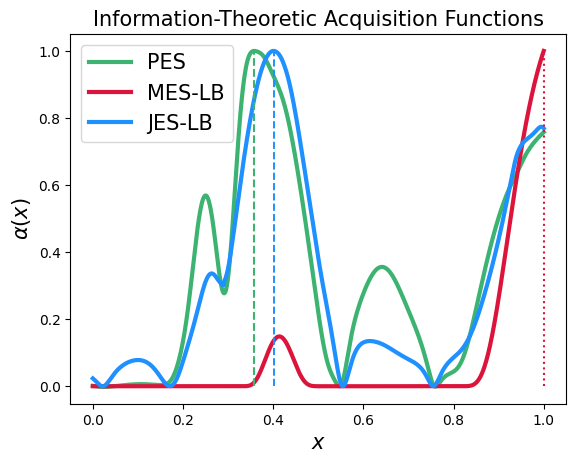

In [8]:
# Plot Acquisition Functions Over Entire Domain
fwd_X = X.unsqueeze(-1).unsqueeze(-1)       # the AFs accept a 3D tensor
scale_acqvals = True                        # ensure AFs live on the same scale

# Evaluate Acquisition Functions
pes_X = pes(fwd_X).detach().numpy()
mes_lb_X = mes_lb(fwd_X).detach().numpy()
jes_lb_X = jes_lb(fwd_X).detach().numpy()

if scale_acqvals:
    pes_X = pes_X / pes_X.max()
    mes_lb_X = mes_lb_X / mes_lb_X.max()
    jes_lb_X = jes_lb_X / jes_lb_X.max()

plt.plot(X, pes_X, color="mediumseagreen", linewidth=3, label="PES")
plt.plot(X, mes_lb_X, color="crimson", linewidth=3, label="MES-LB")
plt.plot(X, jes_lb_X, color="dodgerblue", linewidth=3, label="JES-LB")

plt.vlines(
    X[pes_X.argmax()], 0, 1, color="mediumseagreen", linewidth=1.5,
    linestyle="--"
)
plt.vlines(
    X[mes_lb_X.argmax()], 0, 1, color="crimson", linewidth=1.5, linestyle=":"
)
plt.vlines(
    X[jes_lb_X.argmax()], 0, 1, color="dodgerblue", linewidth=1.4,
    linestyle="--"
)
plt.legend(fontsize=15)
plt.xlabel("$x$", fontsize=15)
plt.ylabel(r"$\alpha(x)$", fontsize=15)
plt.title("Information-Theoretic Acquisition Functions", fontsize=15)
plt.show()

We can maximize the acquisition function within a standard Bayesian optimization loop using standard optimization routines. However, since the PES acquisition function may not be differentiable at certain points, we will use a finite difference approach to optimize PES.

In [9]:
# Maximize Acquisition Functions
from botorch.optim import optimize_acqf

candidate, acq_value = optimize_acqf(
    acq_function=pes,
    bounds=bounds,
    q=1,
    num_restarts=4,
    raw_samples=256,
    options={"with_grad": False},
)
print(f"PES: candidate={candidate}, acq_value={acq_value}")

candidate, acq_value = optimize_acqf(
    acq_function=mes_lb,
    bounds=bounds,
    q=1,
    num_restarts=4,
    raw_samples=256,
)
print(f"MES-LB:, candidate={candidate}, acq_value={acq_value}")

candidate, acq_value = optimize_acqf(
    acq_function=jes_lb,
    bounds=bounds,
    q=1,
    num_restarts=4,
    raw_samples=256,
)
print(f"JES-LB: candidate={candidate}, acq_value={acq_value}")

PES: candidate=tensor([[0.3580]], dtype=torch.float64), acq_value=0.1971753818790028
MES-LB:, candidate=tensor([[1.]], dtype=torch.float64), acq_value=0.02155558019962198
JES-LB: candidate=tensor([[0.4009]], dtype=torch.float64), acq_value=0.5871791664993515


## Multi-Objective Example
Here, we will work through a multi-objective example of information-theoretic acquisition functions in BoTorch. Just as in the single-objective example above, we begin by generating some data and fitting the model.

In [10]:
from botorch.acquisition.multi_objective.utils import (
    compute_sample_box_decomposition,
    random_search_optimizer,
    sample_optimal_points,
)
from botorch.test_functions.multi_objective import ZDT1

d = 4   # number of dimensions
M = 2   # number of objectives
n = 8   # number of samples

q = 2 if SMOKE_TEST else 4

# Define Problem and Bounds
problem = ZDT1(dim=d, num_objectives=M, noise_std=0, negate=True)
bounds = problem.bounds.to(**tkwargs)

# Generate Training Data
train_X = draw_sobol_samples(bounds=bounds, n=n, q=1, seed=123).squeeze(-2)
train_Y = problem(train_X)

# Fit GP Model
model = fit_model(train_X, train_Y, n_outputs=M)

Next, we need to obtain Monte Carlo samples of the optimal inputs and outputs.

In [11]:
# Obtain Monte Carlo Samples
n_pareto_samples = 8
n_pareto_points = 8

optimizer_kwargs = {
    "pop_size": 500,
    "max_tries": 10,
}

ps, pf = sample_optimal_points(
    model=model,
    bounds=bounds,
    num_samples=n_pareto_samples,
    num_points=n_pareto_points,
    optimizer=random_search_optimizer,
    optimizer_kwargs=optimizer_kwargs,
)

Initialize the acquisition functions in the same manner as before.

In [12]:
from botorch.acquisition.multi_objective.joint_entropy_search import (
    qLowerBoundMultiObjectiveJointEntropySearch,
)
from botorch.acquisition.multi_objective.max_value_entropy_search import (
    qLowerBoundMultiObjectiveMaxValueEntropySearch,
)
from botorch.acquisition.multi_objective.predictive_entropy_search import (
    qMultiObjectivePredictiveEntropySearch,
)

pes = qMultiObjectivePredictiveEntropySearch(
    model=model,
    pareto_sets=ps
)

# Compute box-decomposition for MES and JES
hypercell_bounds = compute_sample_box_decomposition(pf)

# Use Lower Bound Estimates for MES and JES
mes_lb = qLowerBoundMultiObjectiveMaxValueEntropySearch(
    model=model,
    hypercell_bounds=hypercell_bounds,
    estimation_type="LB",
)

jes_lb = qLowerBoundMultiObjectiveJointEntropySearch(
    model=model,
    pareto_sets=ps,
    pareto_fronts=pf,
    hypercell_bounds=hypercell_bounds,
    estimation_type="LB",
)

Finally, we can optimize the batch acquisition functions. We directly optimize batch PES while MES and JES use a sequential strategy.

In [13]:
candidates, acq_values = optimize_acqf(
    acq_function=pes,
    bounds=bounds,
    q=q,
    num_restarts=4,
    raw_samples=256,
    options={"with_grad": False},
)
print(f"PES: \ncandidates={candidates}")

PES: 
candidates=tensor([[0.0180, 0.5643, 0.0800, 0.1485],
        [0.0075, 0.0192, 0.3730, 0.1632],
        [0.0000, 1.0000, 1.0000, 0.0000],
        [0.0000, 0.1691, 0.8440, 0.0000]], dtype=torch.float64)


In [14]:
candidates, acq_values = optimize_acqf(
    acq_function=mes_lb,
    bounds=bounds,
    q=q,
    num_restarts=4,
    raw_samples=512,
    sequential=True,
)
print(f"MES-LB: \ncandidates={candidates}")

MES-LB: 
candidates=tensor([[0.0000, 0.0000, 1.0000, 1.0000],
        [0.0000, 0.1948, 0.6284, 0.0000],
        [0.0000, 1.0000, 1.0000, 1.0000],
        [0.0000, 0.1079, 0.0000, 1.0000]], dtype=torch.float64)


In [15]:
candidates, acq_values = optimize_acqf(
    acq_function=jes_lb,
    bounds=bounds,
    q=q,
    num_restarts=4,
    raw_samples=512,
    sequential=True,
)
print(f"JES-LB: \ncandidates={candidates}")

JES-LB: 
candidates=tensor([[0.0000, 0.8340, 0.8804, 0.7352],
        [0.0000, 0.2053, 0.9372, 0.4867],
        [0.0000, 0.0752, 0.3211, 0.2354],
        [0.0011, 0.4704, 0.9548, 0.8901]], dtype=torch.float64)
